In [40]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [47]:
df = pd.read_excel(r"G:\My Drive\3. Carino\MSC\Dissertation\ML\Gender Prediction using FootPrints\dataset\dataset_150.xlsx")


In [48]:
df.head()


,S_No,FootSide,Foot_Length_cm,Foot_Breadth_cm,Foot_Index,Midfoot_Width_cm,Toe1_Length_cm,Toe2_Length_cm,Toe3_Length_cm,Toe4_Length_cm,Toe5_Length_cm,Ball_Breadth_cm,Breadth_Ball_index,Heel_Breadth_cm,Heel_Breadth_Index,Arch_Length_cm,Arch_Index,Sex
0,1,Left,23.0,8.0,34.8,2.4,22.4,22.5,21.2,19.9,18.5,8.3,37.1,4.6,20.5,7.5,0.16,Male
1,2,Left,23.7,7.0,29.5,1.6,22.5,21.5,20.5,19.5,18.5,8.8,39.1,5.0,22.2,9.0,0.10,Male
2,3,Left,23.5,8.3,35.3,0.5,23.6,23.6,22.5,21.5,19.3,8.9,37.7,4.5,19.1,8.5,0.04,Male
3,4,Left,22.3,7.7,34.5,1.3,22.5,22.5,22.0,21.0,19.4,8.8,39.1,4.4,19.6,8.0,0.09,Male
4,5,Left,23.8,8.5,35.7,2.0,23.7,22.7,22.0,21.3,19.9,9.4,39.7,5.2,21.9,8.0,0.12,Male


### Data Prepration

In [49]:
# Randomize the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head()


,S_No,FootSide,Foot_Length_cm,Foot_Breadth_cm,Foot_Index,Midfoot_Width_cm,Toe1_Length_cm,Toe2_Length_cm,Toe3_Length_cm,Toe4_Length_cm,Toe5_Length_cm,Ball_Breadth_cm,Breadth_Ball_index,Heel_Breadth_cm,Heel_Breadth_Index,Arch_Length_cm,Arch_Index,Sex
0,74,Right,24.5,9.0,36.7,2.9,24.5,24.2,23.4,21.7,20.0,9.7,39.6,5.5,22.4,8.3,0.16,Male
1,19,Left,23.0,8.0,34.8,1.5,24.0,23.5,22.3,21.3,20.0,9.2,38.3,4.6,19.2,8.5,0.10,Male
2,119,Left,20.3,7.0,34.5,0.5,19.7,20.2,19.6,18.5,17.4,7.3,37.1,4.2,21.3,7.9,0.04,Female
3,79,Right,24.4,8.5,34.8,5.2,24.5,23.6,22.8,21.7,20.4,9.9,40.4,5.4,22.0,5.0,0.25,Male
4,77,Right,25.8,10.2,39.5,5.5,26.0,25.0,24.4,23.0,21.5,10.3,39.6,5.9,22.7,0.0,0.25,Male


In [50]:
#drop unnecessary columns
df = df.drop(columns=['S_No']).copy()


In [51]:
df.head()


,FootSide,Foot_Length_cm,Foot_Breadth_cm,Foot_Index,Midfoot_Width_cm,Toe1_Length_cm,Toe2_Length_cm,Toe3_Length_cm,Toe4_Length_cm,Toe5_Length_cm,Ball_Breadth_cm,Breadth_Ball_index,Heel_Breadth_cm,Heel_Breadth_Index,Arch_Length_cm,Arch_Index,Sex
0,Right,24.5,9.0,36.7,2.9,24.5,24.2,23.4,21.7,20.0,9.7,39.6,5.5,22.4,8.3,0.16,Male
1,Left,23.0,8.0,34.8,1.5,24.0,23.5,22.3,21.3,20.0,9.2,38.3,4.6,19.2,8.5,0.10,Male
2,Left,20.3,7.0,34.5,0.5,19.7,20.2,19.6,18.5,17.4,7.3,37.1,4.2,21.3,7.9,0.04,Female
3,Right,24.4,8.5,34.8,5.2,24.5,23.6,22.8,21.7,20.4,9.9,40.4,5.4,22.0,5.0,0.25,Male
4,Right,25.8,10.2,39.5,5.5,26.0,25.0,24.4,23.0,21.5,10.3,39.6,5.9,22.7,0.0,0.25,Male


In [52]:
# --- Step 1A: Encode categorical columns ---
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df_encoded = df.copy()

# Label Encoding for categorical columns
label_cols = ['Sex', 'FootSide']
le = LabelEncoder()
for col in label_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])


In [53]:
df_encoded.head()
#Foorside: Left-0, Right-1
# Sex: Female-0, Male-1


,FootSide,Foot_Length_cm,Foot_Breadth_cm,Foot_Index,Midfoot_Width_cm,Toe1_Length_cm,Toe2_Length_cm,Toe3_Length_cm,Toe4_Length_cm,Toe5_Length_cm,Ball_Breadth_cm,Breadth_Ball_index,Heel_Breadth_cm,Heel_Breadth_Index,Arch_Length_cm,Arch_Index,Sex
0,1,24.5,9.0,36.7,2.9,24.5,24.2,23.4,21.7,20.0,9.7,39.6,5.5,22.4,8.3,0.16,1
1,0,23.0,8.0,34.8,1.5,24.0,23.5,22.3,21.3,20.0,9.2,38.3,4.6,19.2,8.5,0.10,1
2,0,20.3,7.0,34.5,0.5,19.7,20.2,19.6,18.5,17.4,7.3,37.1,4.2,21.3,7.9,0.04,0
3,1,24.4,8.5,34.8,5.2,24.5,23.6,22.8,21.7,20.4,9.9,40.4,5.4,22.0,5.0,0.25,1
4,1,25.8,10.2,39.5,5.5,26.0,25.0,24.4,23.0,21.5,10.3,39.6,5.9,22.7,0.0,0.25,1


In [54]:
# --- Step 1B: Define X (features) and y (target) ---
X = df_encoded.drop(columns=['Sex'])
Y = df_encoded['Sex']


In [55]:
X.head()


,FootSide,Foot_Length_cm,Foot_Breadth_cm,Foot_Index,Midfoot_Width_cm,Toe1_Length_cm,Toe2_Length_cm,Toe3_Length_cm,Toe4_Length_cm,Toe5_Length_cm,Ball_Breadth_cm,Breadth_Ball_index,Heel_Breadth_cm,Heel_Breadth_Index,Arch_Length_cm,Arch_Index
0,1,24.5,9.0,36.7,2.9,24.5,24.2,23.4,21.7,20.0,9.7,39.6,5.5,22.4,8.3,0.16
1,0,23.0,8.0,34.8,1.5,24.0,23.5,22.3,21.3,20.0,9.2,38.3,4.6,19.2,8.5,0.10
2,0,20.3,7.0,34.5,0.5,19.7,20.2,19.6,18.5,17.4,7.3,37.1,4.2,21.3,7.9,0.04
3,1,24.4,8.5,34.8,5.2,24.5,23.6,22.8,21.7,20.4,9.9,40.4,5.4,22.0,5.0,0.25
4,1,25.8,10.2,39.5,5.5,26.0,25.0,24.4,23.0,21.5,10.3,39.6,5.9,22.7,0.0,0.25


In [56]:
Y.head()


0    1
1    1
2    0
3    1
4    1
Name: Sex, dtype: int64

In [57]:
# --- Step 1C: Train–Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)



In [58]:
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (120, 16)
Test set: (30, 16)


In [59]:
# --- Step 1D: Scale features (Tree models don’t need it, but SVM does) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [60]:
X_train_scaled


array([[-0.68074565,  0.11531229, -0.94690231, ..., -1.75939174,
        -1.75103788,  0.29218032],
       [ 1.46897745, -0.07001104, -0.39315827, ..., -1.23491182,
        -0.02046909, -0.45381199],
       [-0.68074565, -0.62598102, -0.72540469, ..., -0.42435194,
         0.4819541 , -0.90140738],
       ...,
       [ 1.46897745,  1.35080116,  0.71432981, ..., -0.80579188,
        -2.30928587,  1.63496649],
       [ 1.46897745,  0.17708674, -0.39315827, ..., -1.04419185,
         0.8169029 ,  0.44137879],
       [-0.68074565, -1.737921  , -1.27914873, ..., -0.09059199,
        -0.41124269, -1.05060584]])

#### Model Training

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [62]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True, random_state=42),
}


In [63]:
# Store results
results = []



📘 Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
           1       0.90      0.90      0.90        20

    accuracy                           0.87        30
   macro avg       0.85      0.85      0.85        30
weighted avg       0.87      0.87      0.87        30



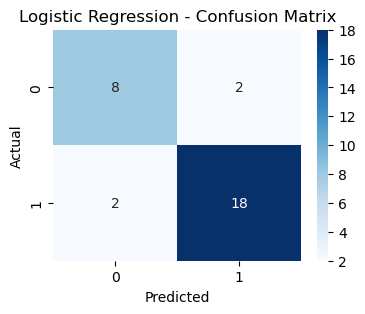


📘 Decision Tree Results:
              precision    recall  f1-score   support

           0       0.67      0.60      0.63        10
           1       0.81      0.85      0.83        20

    accuracy                           0.77        30
   macro avg       0.74      0.72      0.73        30
weighted avg       0.76      0.77      0.76        30



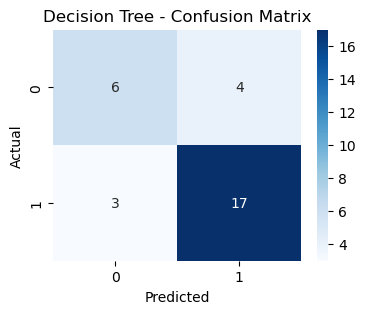


📘 Random Forest Results:
              precision    recall  f1-score   support

           0       0.75      0.60      0.67        10
           1       0.82      0.90      0.86        20

    accuracy                           0.80        30
   macro avg       0.78      0.75      0.76        30
weighted avg       0.80      0.80      0.79        30



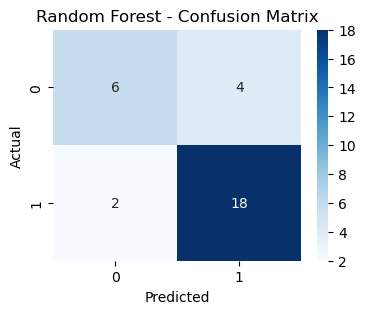


📘 XGBoost Results:
              precision    recall  f1-score   support

           0       0.67      0.60      0.63        10
           1       0.81      0.85      0.83        20

    accuracy                           0.77        30
   macro avg       0.74      0.72      0.73        30
weighted avg       0.76      0.77      0.76        30



c:\Users\jaina\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:22:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


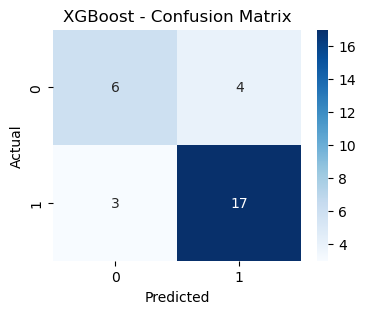


📘 SVM (RBF Kernel) Results:
              precision    recall  f1-score   support

           0       0.78      0.70      0.74        10
           1       0.86      0.90      0.88        20

    accuracy                           0.83        30
   macro avg       0.82      0.80      0.81        30
weighted avg       0.83      0.83      0.83        30



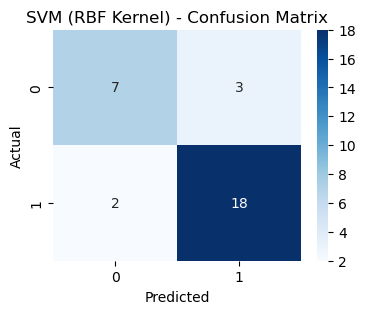

In [64]:
# --- Step 2A: Train all models ---
for name, model in models.items():
    # Scale only for SVM
    if "SVM" in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

    print(f"\n📘 {name} Results:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [65]:
# --- Model Comparison ---
results_df = pd.DataFrame(results)
display(results_df)


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.866667,0.900000,0.90,0.900000
1,Decision Tree,0.766667,0.809524,0.85,0.829268
2,Random Forest,0.800000,0.818182,0.90,0.857143
3,XGBoost,0.766667,0.809524,0.85,0.829268
4,SVM (RBF Kernel),0.833333,0.857143,0.90,0.878049


C:\Users\jaina\AppData\Local\Temp\ipykernel_10916\4184393185.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


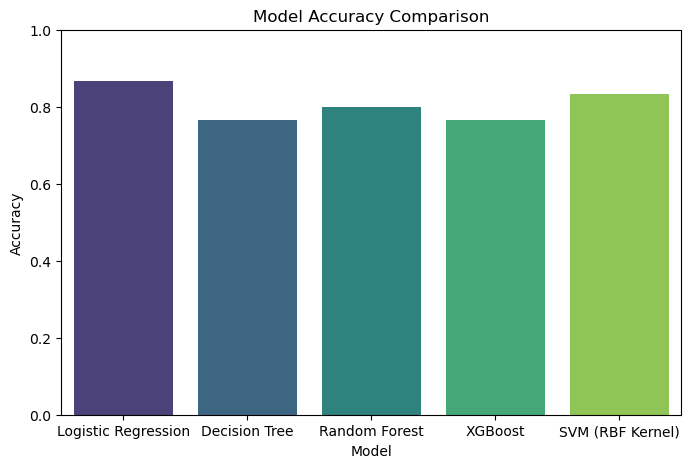

In [66]:
# --- Models Visual Comparison ---
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()


### Cross Validation

In [67]:
# --- Cross-Validation (using StratifiedKFold) ---
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Use the same split for all models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}


In [68]:
for name, model in models.items():
    if "SVM" in name:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    else:
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

    cv_results[name] = scores.mean()
    print(f"✅ {name} | CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")


✅ Logistic Regression | CV Accuracy: 0.9000 ± 0.0333
✅ Decision Tree | CV Accuracy: 0.8417 ± 0.0808
✅ Random Forest | CV Accuracy: 0.8833 ± 0.0312
✅ XGBoost | CV Accuracy: 0.8917 ± 0.0204


c:\Users\jaina\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:22:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\jaina\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:22:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\jaina\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:22:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\jaina\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:22:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

✅ SVM (RBF Kernel) | CV Accuracy: 0.8917 ± 0.0333


In [69]:
# Compare Cross Validation(CV) results
cv_df = pd.DataFrame(list(cv_results.items()), columns=['Model', 'CV Accuracy'])
display(cv_df)


,Model,CV Accuracy
0,Logistic Regression,0.900000
1,Decision Tree,0.841667
2,Random Forest,0.883333
3,XGBoost,0.891667
4,SVM (RBF Kernel),0.891667


C:\Users\jaina\AppData\Local\Temp\ipykernel_10916\1158445831.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='CV Accuracy', data=cv_df, palette='mako')


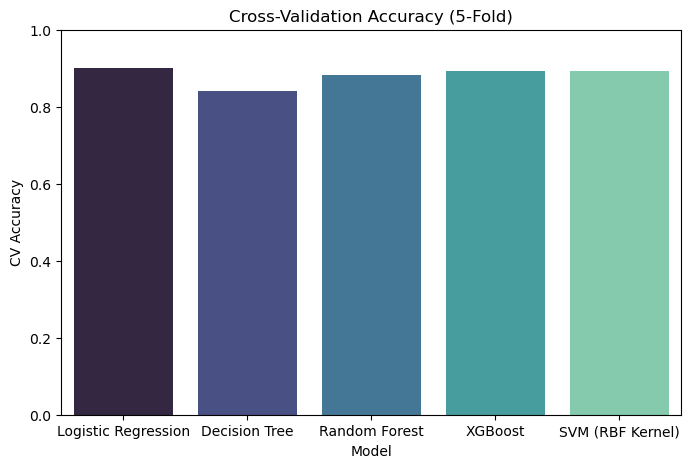

In [70]:
# Compare Cross Validation(CV) results Visually
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='CV Accuracy', data=cv_df, palette='mako')
plt.title("Cross-Validation Accuracy (5-Fold)")
plt.ylim(0,1)
plt.show()


### Hyperparameter Tuning (Random Search)

In [73]:
# Hyperparameter Tuning for all models (Logistic Regression, Decision Tree, Random Forest, XGBoost, SVM)

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Logistic Regression Hyperparameter Tuning Prarameters
param_grid_lr = {
    'penalty': ['l2', None],                      # 'l1' requires solvers like 'liblinear' or 'saga'
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],
    'class_weight': [None, 'balanced'],
    'max_iter': [200, 500, 1000],
    'tol': [1e-4, 1e-3, 1e-2]
}

# Decision Tree Hyperparameter Tuning Prarameters
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 3, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2', 0.2, 0.5],
    'class_weight': [None, 'balanced']
}

# Random Forest Hyperparameter Tuning Prarameters
param_grid_rf = {
    'n_estimators': [50, 100, 200, 500],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None, 0.3, 0.5],
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

# XGBoost Hyperparameter Tuning Prarameters
param_grid_xgb = {
    'n_estimators': [50, 100, 200, 400],
    'max_depth': [3, 4, 6, 8],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],
    'subsample': [0.5, 0.7, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.7, 0.9, 1.0],
    'colsample_bylevel': [0.5, 0.7, 0.9],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.5, 1, 5, 10],
    'scale_pos_weight': [1, sum(y_train==0)/sum(y_train==1)],  # for imbalance
    'gamma': [0, 0.1, 0.5, 1]
}

# SVM Hyperparameter Tuning Prarameters
param_grid_svm = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'degree': [2, 3, 4],            # only for 'poly'
    'coef0': [0.0, 0.1, 0.5],       # for 'poly' and 'sigmoid'
    'class_weight': [None, 'balanced'],
    'shrinking': [True, False]
}


In [74]:
# Randomized Search CV
random_search_results = {}
for name, model in models.items():
    if name == "Logistic Regression":
        param_grid = param_grid_lr
    elif name == "Decision Tree":
        param_grid = param_grid_dt
    elif name == "Random Forest":
        param_grid = param_grid_rf
    elif name == "XGBoost":
        param_grid = param_grid_xgb
    elif name == "SVM (RBF Kernel)":
        param_grid = param_grid_svm
    else:
        continue

    if "SVM" in name:
        rs_cv = RandomizedSearchCV(model, param_distributions=param_grid, n_iter=20, scoring='accuracy', cv=StratifiedKFold(n_splits=5), random_state=42, n_jobs=-1)
        rs_cv.fit(X_train_scaled, y_train)
    else:
        rs_cv = RandomizedSearchCV(model, param_distributions=param_grid, n_iter=20, scoring='accuracy', cv=StratifiedKFold(n_splits=5), random_state=42, n_jobs=-1)
        rs_cv.fit(X_train, y_train)

    random_search_results[name] = {
        'Best Parameters': rs_cv.best_params_,
        'Best CV Score': rs_cv.best_score_
    }

    print(f"\n🎯 {name} - Best CV Score: {rs_cv.best_score_:.4f}")
    print("Best Parameters:", rs_cv.best_params_)


c:\Users\jaina\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(



🎯 Logistic Regression - Best CV Score: 0.9083
Best Parameters: {'tol': 0.001, 'solver': 'lbfgs', 'penalty': None, 'max_iter': 500, 'class_weight': 'balanced', 'C': 0.1}

🎯 Decision Tree - Best CV Score: 0.8667
Best Parameters: {'splitter': 'best', 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 3, 'criterion': 'entropy', 'class_weight': 'balanced'}

🎯 Random Forest - Best CV Score: 0.9083
Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10, 'criterion': 'entropy', 'class_weight': 'balanced_subsample', 'bootstrap': False}


c:\Users\jaina\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:23:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🎯 XGBoost - Best CV Score: 0.9083
Best Parameters: {'subsample': 1.0, 'scale_pos_weight': 1, 'reg_lambda': 5, 'reg_alpha': 0.01, 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 1.0, 'colsample_bylevel': 0.5}

🎯 SVM (RBF Kernel) - Best CV Score: 0.9000
Best Parameters: {'shrinking': False, 'kernel': 'linear', 'gamma': 'scale', 'degree': 2, 'coef0': 0.1, 'class_weight': 'balanced', 'C': 10}


c:\Users\jaina\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(



🚀 Logistic Regression Tuned Results:
              precision    recall  f1-score   support

           0       0.67      0.80      0.73        10
           1       0.89      0.80      0.84        20

    accuracy                           0.80        30
   macro avg       0.78      0.80      0.78        30
weighted avg       0.81      0.80      0.80        30



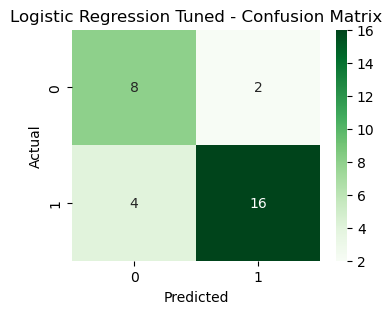


🚀 Decision Tree Tuned Results:
              precision    recall  f1-score   support

           0       0.71      0.50      0.59        10
           1       0.78      0.90      0.84        20

    accuracy                           0.77        30
   macro avg       0.75      0.70      0.71        30
weighted avg       0.76      0.77      0.75        30



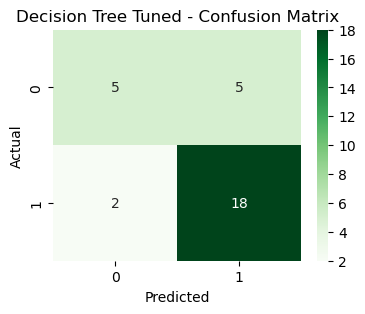


🚀 Random Forest Tuned Results:
              precision    recall  f1-score   support

           0       0.78      0.70      0.74        10
           1       0.86      0.90      0.88        20

    accuracy                           0.83        30
   macro avg       0.82      0.80      0.81        30
weighted avg       0.83      0.83      0.83        30



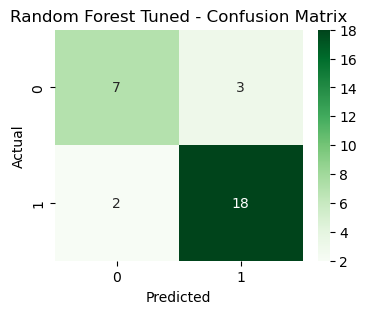

c:\Users\jaina\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:23:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🚀 XGBoost Tuned Results:
              precision    recall  f1-score   support

           0       0.67      0.60      0.63        10
           1       0.81      0.85      0.83        20

    accuracy                           0.77        30
   macro avg       0.74      0.72      0.73        30
weighted avg       0.76      0.77      0.76        30



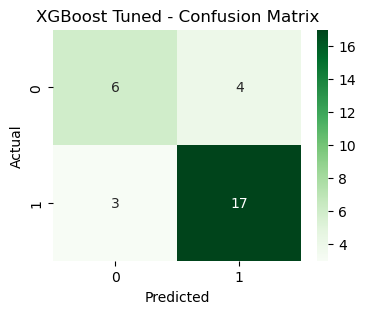


🚀 SVM (RBF Kernel) Tuned Results:
              precision    recall  f1-score   support

           0       0.62      0.80      0.70        10
           1       0.88      0.75      0.81        20

    accuracy                           0.77        30
   macro avg       0.75      0.78      0.75        30
weighted avg       0.79      0.77      0.77        30



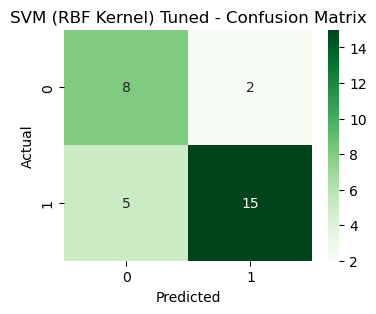

In [75]:
# Evaluate Tuned Models, store and Compare
tuned_models_results = []

for name, model in models.items():
    best_params = random_search_results[name]['Best Parameters']
    model.set_params(**best_params)

    if "SVM" in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n🚀 {name} Tuned Results:")
    print(classification_report(y_test, y_pred))
    
    tuned_models_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    }) 

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(f"{name} Tuned - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [76]:
# Tuned Model Comparison DataFrame
tuned_model_results_df = pd.DataFrame(tuned_models_results)
tuned_model_results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.800000,0.888889,0.80,0.842105
1,Decision Tree,0.766667,0.782609,0.90,0.837209
2,Random Forest,0.833333,0.857143,0.90,0.878049
3,XGBoost,0.766667,0.809524,0.85,0.829268
4,SVM (RBF Kernel),0.766667,0.882353,0.75,0.810811


C:\Users\jaina\AppData\Local\Temp\ipykernel_10916\3780848332.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=tuned_model_results_df, palette='plasma')


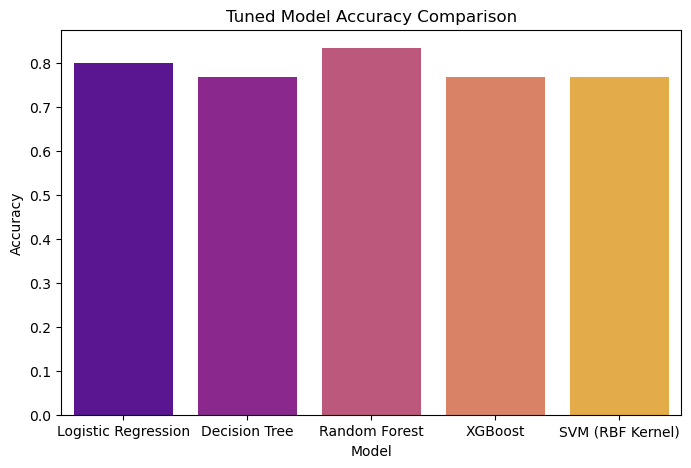

In [77]:
# Tuned Model Comparison Visually
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=tuned_model_results_df, palette='plasma')
plt.title("Tuned Model Accuracy Comparison")
plt.show()


### Feture Importance and Model Interpretability

In [78]:
# get feature importance for the best model
best_model_name = tuned_model_results_df.sort_values(by='Accuracy', ascending=False).iloc[0]['Model']

best_model = models[best_model_name]
print(f"Best Model: {best_model_name}")


Best Model: Random Forest


C:\Users\jaina\AppData\Local\Temp\ipykernel_10916\240139493.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='crest')


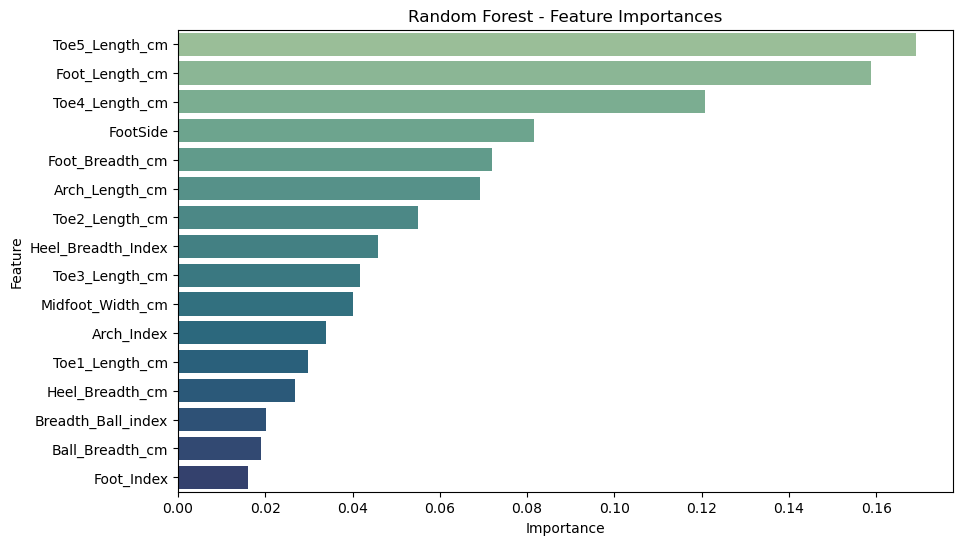

In [79]:
feature_importances = best_model.feature_importances_
feature_names = X.columns

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='crest')
plt.title(f"{best_model_name} - Feature Importances")
plt.show()


In [80]:
# Print Before and After Tuning Comparison
print("Before Tuning:")
display(results_df)

print("After Tuning:")
display(tuned_model_results_df)


Before Tuning:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.866667,0.900000,0.90,0.900000
1,Decision Tree,0.766667,0.809524,0.85,0.829268
2,Random Forest,0.800000,0.818182,0.90,0.857143
3,XGBoost,0.766667,0.809524,0.85,0.829268
4,SVM (RBF Kernel),0.833333,0.857143,0.90,0.878049


After Tuning:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.800000,0.888889,0.80,0.842105
1,Decision Tree,0.766667,0.782609,0.90,0.837209
2,Random Forest,0.833333,0.857143,0.90,0.878049
3,XGBoost,0.766667,0.809524,0.85,0.829268
4,SVM (RBF Kernel),0.766667,0.882353,0.75,0.810811


### Learning Curve Analysis

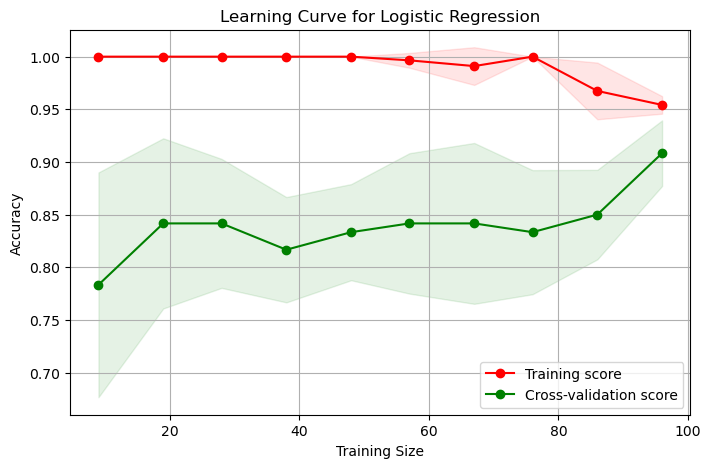

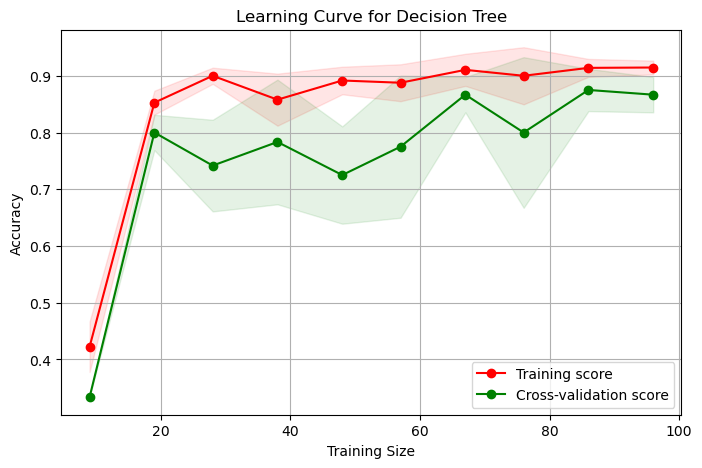

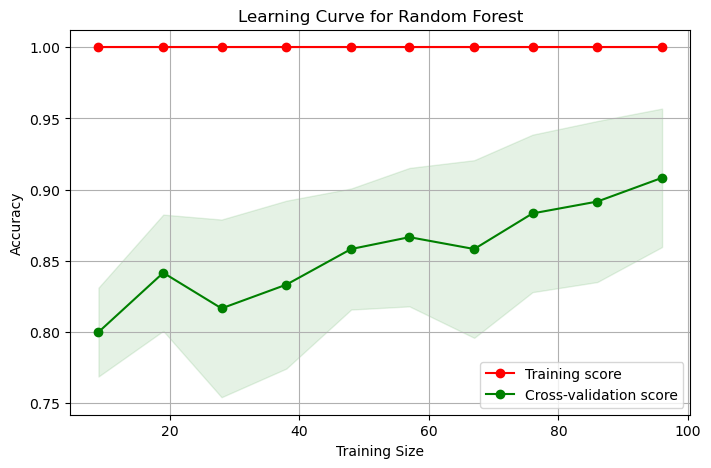

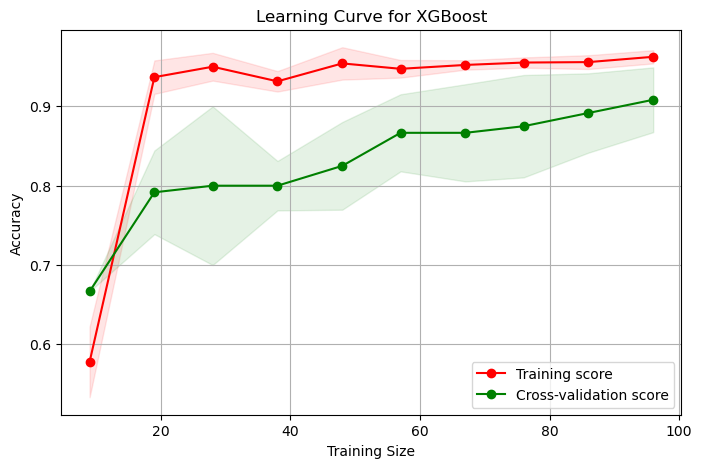

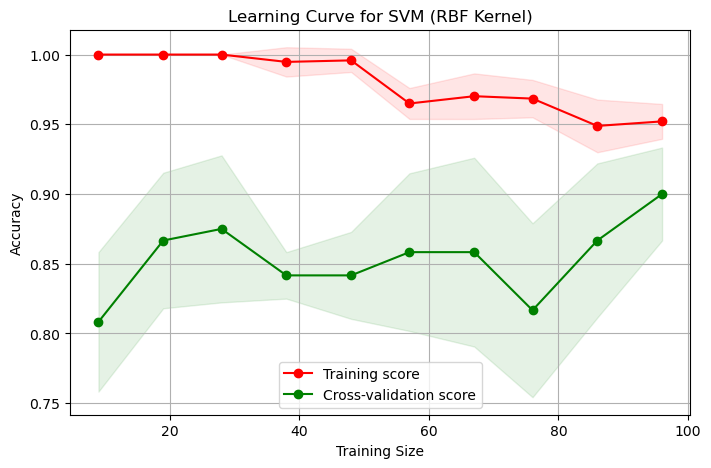

In [81]:
#Learning Curves for all Models
from sklearn.model_selection import learning_curve

for name, model in models.items():
    if "SVM" in name:
        X_data, y_data = X_train_scaled, y_train
    else:
        X_data, y_data = X_train, y_train

    train_sizes, train_scores, test_scores = learning_curve(model, X_data, y_data, cv=StratifiedKFold(n_splits=5), scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), random_state=42)

    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-validation score')
    
    plt.fill_between(train_sizes, train_scores_mean - np.std(train_scores, axis=1),
                        train_scores_mean + np.std(train_scores, axis=1), alpha=0.1, color='r') # SHows the std deviation area
    
    plt.fill_between(train_sizes, test_scores_mean - np.std(test_scores, axis=1),
                        test_scores_mean + np.std(test_scores, axis=1), alpha=0.1, color='g')
    
    plt.title(f'Learning Curve for {name}')
    plt.xlabel('Training Size')
    plt.ylabel('Accuracy')
    plt.legend(loc='best')
    plt.grid()
    plt.show()


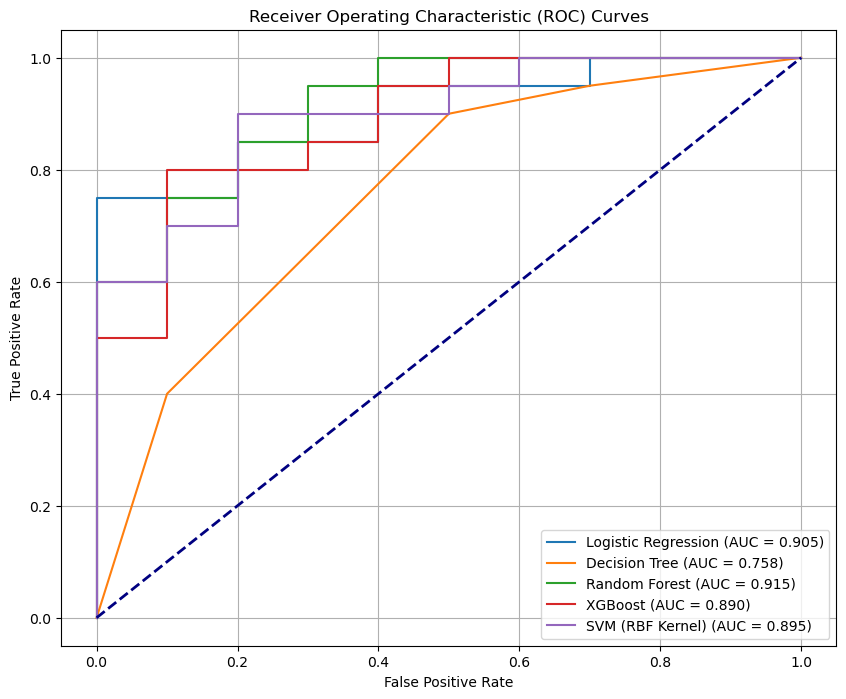

In [82]:
# ROC-AUC Curves for tuned models
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(10, 8))

for name, model in models.items():
    if "SVM" in name:
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.grid()
plt.legend(loc="lower right")
plt.show()


## Voting Ensemble Classifier Models

c:\Users\jaina\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\jaina\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:23:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🤖 Voting Classifier Ensemble Accuracy: 0.8667
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
           1       0.90      0.90      0.90        20

    accuracy                           0.87        30
   macro avg       0.85      0.85      0.85        30
weighted avg       0.87      0.87      0.87        30



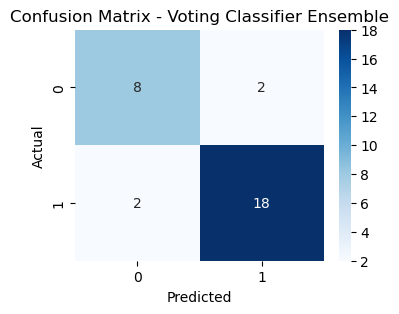

,Model,Accuracy,Precision,Recall,F1 Score
0,Voting Classifier Ensemble,0.866667,0.9,0.9,0.9


In [83]:
# Voting Classifier Ensemble for Tuned Models
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[(name, model) for name, model in models.items()],
    voting='soft'  # Use 'soft' voting to consider predicted probabilities
)

voting_clf.fit(X_train, y_train)

y_pred_ensemble = voting_clf.predict(X_test)
acc_ensemble = accuracy_score(y_test, y_pred_ensemble)
print(f"\n🤖 Voting Classifier Ensemble Accuracy: {acc_ensemble:.4f}")
print(classification_report(y_test, y_pred_ensemble))

# Confusion Matrix for Ensemble
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(4,3))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Voting Classifier Ensemble')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Ensemble Model Results DataFrame
ensemble_results_df = pd.DataFrame([{
    'Model': 'Voting Classifier Ensemble',
    'Accuracy': acc_ensemble,
    'Precision': precision_score(y_test, y_pred_ensemble),
    'Recall': recall_score(y_test, y_pred_ensemble),
    'F1 Score': f1_score(y_test, y_pred_ensemble)
}])
display(ensemble_results_df)


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.800000,0.888889,0.80,0.842105
1,Decision Tree,0.766667,0.782609,0.90,0.837209
2,Random Forest,0.833333,0.857143,0.90,0.878049
3,XGBoost,0.766667,0.809524,0.85,0.829268
4,SVM (RBF Kernel),0.766667,0.882353,0.75,0.810811
5,Voting Classifier Ensemble,0.866667,0.900000,0.90,0.900000


C:\Users\jaina\AppData\Local\Temp\ipykernel_10916\690751151.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=final_comparison_df, palette='coolwarm')


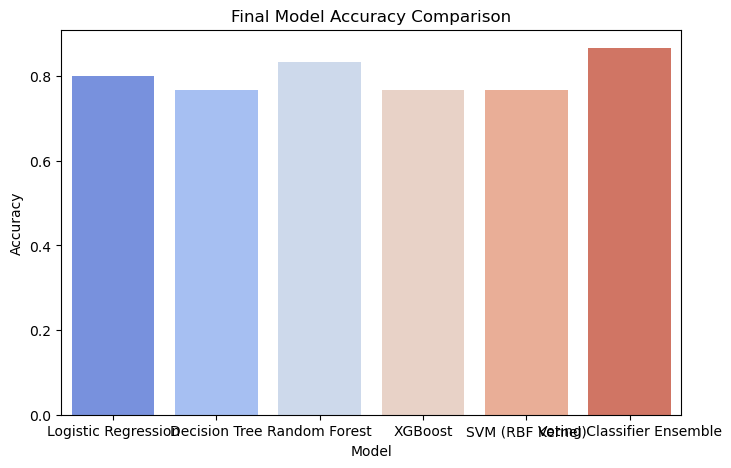

In [84]:
# Final all tuned models comparison
final_comparison_df = pd.concat([tuned_model_results_df, ensemble_results_df], ignore_index=True)
display(final_comparison_df)
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=final_comparison_df, palette='coolwarm')
plt.title("Final Model Accuracy Comparison")
plt.show()


### Making Predictions

In [85]:
# Making Predictions on New Data with all tuned models
predictions = pd.DataFrame({'Actual Sex': y_test})

for name, model in models.items():
    if "SVM" in name:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    predictions[name + ' Prediction'] = y_pred
    
# Ensemble Prediction
y_pred_ensemble = voting_clf.predict(X_test)
predictions['Ensemble Prediction'] = y_pred_ensemble

display(predictions.head(10))


,Actual Sex,Logistic Regression Prediction,Decision Tree Prediction,Random Forest Prediction,XGBoost Prediction,SVM (RBF Kernel) Prediction,Ensemble Prediction
50,1,1,1,1,1,1,1
77,1,1,1,1,1,1,1
84,1,1,1,1,1,1,1
133,0,1,0,1,1,1,1
1,1,1,1,1,1,1,1
4,1,1,1,1,1,1,1
144,1,0,1,1,1,0,1
126,0,0,1,0,0,0,0
101,1,0,1,0,0,0,0
9,1,1,1,1,1,1,1


### Saving All Tuned Models

In [86]:
# Saving all tuned models using joblib
import joblib
import os


# Create a directory to store the models if it doesn't exist
save_path = r"models"
if not os.path.exists(save_path):
    os.makedirs(save_path)
    
for name, model in models.items():
    model_filename = os.path.join(save_path, f"{name.replace(' ', '_').lower()}_tuned_model.joblib")
    joblib.dump(model, model_filename)
    print(f"💾 Saved {name} to {model_filename}")

# Save the scaler as well (important for preprocessing new data)
joblib.dump(scaler, os.path.join(save_path, "scaler.pkl"))
print(f"💾 Saved Scaler to {os.path.join(save_path, 'scaler.pkl')}")

# Save the Voting Classifier Ensemble
ensemble_model_filename = os.path.join(save_path, "voting_classifier_ensemble_model.joblib")
joblib.dump(voting_clf, ensemble_model_filename)
print(f"💾 Saved Voting Classifier Ensemble to {ensemble_model_filename}")



💾 Saved Logistic Regression to models\logistic_regression_tuned_model.joblib
💾 Saved Decision Tree to models\decision_tree_tuned_model.joblib
💾 Saved Random Forest to models\random_forest_tuned_model.joblib
💾 Saved XGBoost to models\xgboost_tuned_model.joblib
💾 Saved SVM (RBF Kernel) to models\svm_(rbf_kernel)_tuned_model.joblib
💾 Saved Scaler to models\scaler.pkl
💾 Saved Voting Classifier Ensemble to models\voting_classifier_ensemble_model.joblib


## Import Models

In [88]:
# Import Models
import joblib
import os

# Load a saved model
model_save_path = r"G:\My Drive\3. Carino\MSC\Dissertation\ML\Gender Prediction using FootPrints\models"

loaded_models = {
    "Logistic Regression": joblib.load(os.path.join(model_save_path, "logistic_regression_tuned_model.joblib")),
    "Decision Tree": joblib.load(os.path.join(model_save_path, "decision_tree_tuned_model.joblib")),
    "Random Forest": joblib.load(os.path.join(model_save_path, "random_forest_tuned_model.joblib")),
    "XGBoost": joblib.load(os.path.join(model_save_path, "xgboost_tuned_model.joblib")),
    "SVM (RBF Kernel)": joblib.load(os.path.join(model_save_path, "svm_(rbf_kernel)_tuned_model.joblib")),
    "Voting Classifier Ensemble": joblib.load(os.path.join(model_save_path, "voting_classifier_ensemble_model.joblib"))
}

# Verify loaded models by making predictions
for name, model in loaded_models.items():
    if "SVM" in name:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ Loaded {name} | Accuracy on Test Set: {acc:.4f}")
    

# Load scaler for SVM (overwrite the local scaler instance if any)
scaler = joblib.load(os.path.join(model_save_path, "scaler.pkl"))
print("✅ Scaler loaded:", isinstance(scaler, StandardScaler))


✅ Loaded Logistic Regression | Accuracy on Test Set: 0.8000
✅ Loaded Decision Tree | Accuracy on Test Set: 0.7667
✅ Loaded Random Forest | Accuracy on Test Set: 0.8333
✅ Loaded XGBoost | Accuracy on Test Set: 0.7667
✅ Loaded SVM (RBF Kernel) | Accuracy on Test Set: 0.7667
✅ Loaded Voting Classifier Ensemble | Accuracy on Test Set: 0.8667
✅ Scaler loaded: True


In [89]:
X_test.head()


,FootSide,Foot_Length_cm,Foot_Breadth_cm,Foot_Index,Midfoot_Width_cm,Toe1_Length_cm,Toe2_Length_cm,Toe3_Length_cm,Toe4_Length_cm,Toe5_Length_cm,Ball_Breadth_cm,Breadth_Ball_index,Heel_Breadth_cm,Heel_Breadth_Index,Arch_Length_cm,Arch_Index
50,1,27.0,10.3,38.1,3.6,25.7,25.0,24.2,23.0,21.2,10.5,40.9,5.6,21.8,10.4,0.18
77,1,22.3,7.8,35.0,0.0,22.5,22.3,21.6,20.5,18.7,8.4,37.3,5.0,22.2,8.6,0.00
84,1,23.3,9.4,40.3,5.0,23.4,23.2,22.2,21.2,19.3,10.4,44.4,5.0,21.4,5.5,0.25
133,0,22.9,8.7,38.0,1.7,23.0,22.4,21.7,20.4,19.5,9.0,39.1,5.2,22.6,7.3,0.11
1,0,23.0,8.0,34.8,1.5,24.0,23.5,22.3,21.3,20.0,9.2,38.3,4.6,19.2,8.5,0.10


In [90]:
# Helpter function to make predictions on new data from all loaded models and show result in dataframe

def predict_new_data(new_data_dict, loaded_models, scaler, X_train_columns):
    """
    Makes predictions on new data using all trained models loaded from files.

    Args:
        new_data_dict (dict): A dictionary containing the new data point,
                              with keys matching the original feature names.
                              'FootSide' can be 'Left' or 'Right' (case-insensitive).
        loaded_models (dict): A dictionary where keys are model names and values
                              are the trained model objects loaded from files.
        scaler: The fitted StandardScaler object used during training.
        X_train_columns (pd.Index): The columns from the training data X.

    Returns:
        pd.DataFrame: A DataFrame containing predictions and confidence scores
                      for each model, with 'Predicted Sex' as 'Female' or 'Male'.
    """
    
    # Convert new data dict to DataFrame
    new_data_df = pd.DataFrame([new_data_dict])

    # Encode 'FootSide'
    if 'FootSide' in new_data_df.columns:
        new_data_df['FootSide'] = new_data_df['FootSide'].str.lower().map({'left': 0, 'right': 1})

    # Ensure all required columns are present
    for col in X_train_columns:
        if col not in new_data_df.columns:
            new_data_df[col] = 0  # or some default value

    # Reorder columns to match training data
    new_data_df = new_data_df[X_train_columns]

    # Make predictions and get confidence scores (probabilities) from each model
    new_predictions_results = []

    for name, model in loaded_models.items():
        if "SVM" in name:
            new_data_scaled = scaler.transform(new_data_df)
            y_proba = model.predict_proba(new_data_scaled)[:, 1]
            y_pred = model.predict(new_data_scaled)
        else:
            y_proba = model.predict_proba(new_data_df)[:, 1]
            y_pred = model.predict(new_data_df)
            
        # Postprocess Predicted Sex: convert 0/1 to 'Female'/'Male'
        predicted_sex_label = 'Male' if y_pred[0] == 1 else 'Female'
         # Get confidence score if the model supports predict_proba
        if hasattr(model, 'predict_proba'):
            probabilities = model.predict_proba(new_data_df)[0]
            confidence = max(probabilities) # Get the probability of the predicted class
        else:
            confidence = "N/A (predict_proba not available)" # SVM needs probability=True

        new_predictions_results.append({
            'Model': name,
            'Predicted Sex': predicted_sex_label,
            'Confidence': confidence
        })
        
    return pd.DataFrame(new_predictions_results)


In [91]:
X.columns


Index(['FootSide', 'Foot_Length_cm', 'Foot_Breadth_cm', 'Foot_Index',
       'Midfoot_Width_cm', 'Toe1_Length_cm', 'Toe2_Length_cm',
       'Toe3_Length_cm', 'Toe4_Length_cm', 'Toe5_Length_cm', 'Ball_Breadth_cm',
       'Breadth_Ball_index', 'Heel_Breadth_cm', 'Heel_Breadth_Index',
       'Arch_Length_cm', 'Arch_Index'],
      dtype='object')

In [92]:
# Prediction on sample data using the helper function
sample_new_data = {
    'FootSide': 'Right',
    'Foot_Length_cm': 25.0,
    'Foot_Breadth_cm': 10.0,
    'Foot_Index': 40.0,
    'Midfoot_Width_cm': 8.0,
    'Toe1_Length_cm': 5.0,
    'Toe2_Length_cm': 4.5,
    'Toe3_Length_cm': 4.0,
    'Toe4_Length_cm': 3.5,
    'Toe5_Length_cm': 3.0,
    'Ball_Breadth_cm': 9.0,
    'Breadth_Ball_index': 36.0,
    'Heel_Breadth_cm': 6.0,
    'Heel_Breadth_Index': 24.0,
    'Arch_Length_cm': 15.0,
    'Arch_Index': 60.0
}

new_data_predictions = predict_new_data(sample_new_data, loaded_models, scaler, X.columns)
display(new_data_predictions)


c:\Users\jaina\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


,Model,Predicted Sex,Confidence
0,Logistic Regression,Male,1.000000
1,Decision Tree,Female,0.875000
2,Random Forest,Male,0.674548
3,XGBoost,Male,0.703719
4,SVM (RBF Kernel),Male,1.000000
5,Voting Classifier Ensemble,Male,0.700651
